In [1]:
# Fourier Neural Operator (FNO) for ERA5 Wave Spectra
# 1D-to-2D FNO: Input 5 channels on frequency grid -> Output 2D directional spectrum
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load processed data (same as MLP)
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30)
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30)
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")  
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")
print(f"b2: {b2.shape}")

# Check for any NaN values in loaded data
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")
print(f"NaN values in b2: {np.isnan(b2).sum()}")

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in S2D: 0
NaN values in a1: 0
NaN values in b1: 0
NaN values in a2: 0
NaN values in b2: 0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2836\32192706.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [3]:
# Prepare inputs for FNO model (channel-wise format)
print("Preparing inputs for FNO model...")

# Create model inputs by stacking ALL features into channels for FNO
# FNO Input: (batch, channels=5, freq=30) where channels = [S1D, a1, b1, a2, b2]
batch_size, n_freq, n_dir = S2D.shape

# Stack all features as channels for FNO (similar to ResNet1)
inputs = np.stack([
    S1D,  # Channel 0: 1D spectrum
    a1,   # Channel 1: First harmonic moment a1
    b1,   # Channel 2: First harmonic moment b1
    a2,   # Channel 3: Second harmonic moment a2
    b2    # Channel 4: Second harmonic moment b2
], axis=1)  # Shape: (batch_size, 5, 30)

# Target is the FULL 2D spectrum (same as MLP)
targets = S2D  # Shape: (batch_size, 30, 24)

print(f"Input shape: {inputs.shape} (batch, channels=5, freq=30)")
print(f"Target shape: {targets.shape} (batch, freq=30, dir=24)")
print(f"Input channels: S1D, a1, b1, a2, b2")

# Check for any remaining NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in targets: {nan_targets}")

if nan_inputs > 0 or nan_targets > 0:
    print("WARNING: NaN values detected! Will clean...")
    # Find rows with any NaN
    input_mask = ~np.isnan(inputs).any(axis=(1,2))
    target_mask = ~np.isnan(targets).any(axis=(1,2))
    valid_mask = input_mask & target_mask
    
    print(f"Valid samples: {valid_mask.sum()}/{len(valid_mask)}")
    
    # Filter out NaN samples
    inputs = inputs[valid_mask]
    targets = targets[valid_mask]
    S2D = S2D[valid_mask]
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned target shape: {targets.shape}")

# Basic statistics
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Target range: [{targets.min():.6f}, {targets.max():.6f}]")
print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")

Preparing inputs for FNO model...
Input shape: (9504, 5, 30) (batch, channels=5, freq=30)
Target shape: (9504, 30, 24) (batch, freq=30, dir=24)
Input channels: S1D, a1, b1, a2, b2
NaN in inputs: 0
NaN in targets: 0
Input range: [-0.991445, 22.504860]
Target range: [0.000000, 19.814178]
Input mean: -0.121308, std: 0.506509
Target mean: 0.025833, std: 0.173907


In [4]:
# Normalize inputs and split data (channel-wise normalization for FNO)
print("Normalizing inputs and splitting data...")

# Normalize inputs channel-wise (like ResNet1, not flattened like MLP)
input_mean = inputs.mean(axis=(0, 2), keepdims=True)  # Mean over batch and frequency
input_std = inputs.std(axis=(0, 2), keepdims=True) + 1e-8  # Std over batch and frequency  
inputs_norm = (inputs - input_mean) / input_std

# Save normalization parameters for later evaluation
os.makedirs("models", exist_ok=True)
np.savez("models/fno_normalization.npz", input_mean=input_mean, input_std=input_std)
print(f"💾 Saved normalization parameters to models/fno_normalization.npz")

# For targets, use raw 2D spectrum without scaling
targets_norm = targets
target_scale = 1.0  # No scaling applied

print(f"Input normalization per channel:")
for i, name in enumerate(['S1D', 'a1', 'b1', 'a2', 'b2']):
    print(f"  {name}: Mean={input_mean[0, i, 0]:.6f}, Std={input_std[0, i, 0]:.6f}")

print(f"Target scaling factor: {target_scale:.6f}")
print(f"Normalized input range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")
print(f"Normalized target range: [{targets_norm.min():.6f}, {targets_norm.max():.6f}]")

# Split data chronologically (proper for time-series wave data)
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Don't shuffle - preserve temporal structure
indices = np.arange(n_samples)  # Chronological order
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], targets_norm[val_idx]
X_test, y_test = inputs_norm[test_idx], targets_norm[test_idx]

# Split 2D spectra for evaluation
S2D_train = S2D[train_idx]
S2D_val = S2D[val_idx]
S2D_test = S2D[test_idx]

print(f"Data splits:")
print(f"Train: {X_train.shape[0]} samples ({X_train.shape})")
print(f"Val: {X_val.shape[0]} samples ({X_val.shape})")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape})")

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

Normalizing inputs and splitting data...
💾 Saved normalization parameters to models/fno_normalization.npz
Input normalization per channel:
  S1D: Mean=0.162311, Std=0.477422
  a1: Mean=0.115850, Std=0.423460
  b1: Mean=-0.516164, Std=0.484411
  a2: Mean=-0.265445, Std=0.396450
  b2: Mean=-0.103093, Std=0.412283
Target scaling factor: 1.000000
Normalized input range: [-2.614872, 46.798307]
Normalized target range: [0.000000, 19.814178]
Data splits:
Train: 6652 samples ((6652, 5, 30))
Val: 1425 samples ((1425, 5, 30))
Test: 1427 samples ((1427, 5, 30))
Using device: cpu


In [2]:
# Fourier Neural Operator Architecture
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super(SpectralConv1d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes  # Number of Fourier modes to multiply

        self.scale = (1 / (in_channels * out_channels))
        self.weights = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes, dtype=torch.cfloat))

    def compl_mul1d(self, input, weights):
        # Complex multiplication
        # (batch, in_channel, x), (in_channel, out_channel, x) -> (batch, out_channel, x)
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        # Compute Fourier coefficients up to factor of e^(- something)
        x_ft = torch.fft.rfft(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1)//2 + 1, 
                             dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes] = self.compl_mul1d(x_ft[:, :, :self.modes], self.weights)

        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x


class FourierLayer(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super(FourierLayer, self).__init__()
        self.conv = SpectralConv1d(in_channels, out_channels, modes)
        self.w = nn.Conv1d(in_channels, out_channels, 1)  # 1x1 convolution for skip connection

    def forward(self, x):
        x1 = self.conv(x)
        x2 = self.w(x)
        return x1 + x2


class FNO1D_to_2D(nn.Module):
    def __init__(self, in_channels=5, width=64, modes=16, n_freq=30, n_dir=24):
        super(FNO1D_to_2D, self).__init__()
        self.modes = modes
        self.width = width
        self.n_freq = n_freq
        self.n_dir = n_dir
        
        # Lifting layer: project from input channels to hidden dimension
        self.fc0 = nn.Linear(in_channels, self.width)
        
        # Fourier layers (typically 4 layers)
        self.fourier0 = FourierLayer(self.width, self.width, self.modes)
        self.fourier1 = FourierLayer(self.width, self.width, self.modes)
        self.fourier2 = FourierLayer(self.width, self.width, self.modes)
        self.fourier3 = FourierLayer(self.width, self.width, self.modes)
        
        # Projection layers to output 2D spectrum
        # From (batch, width, n_freq) to (batch, n_freq, n_dir)
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, self.n_dir)
        
        self.activation = nn.GELU()
        
    def forward(self, x):
        # x shape: (batch, in_channels=5, n_freq=30)
        
        # Transpose for point-wise operations: (batch, n_freq, in_channels)
        x = x.permute(0, 2, 1)
        
        # Lifting: (batch, n_freq, in_channels) -> (batch, n_freq, width)
        x = self.fc0(x)
        
        # Transpose back for spectral convolutions: (batch, width, n_freq)
        x = x.permute(0, 2, 1)
        
        # Apply Fourier layers with residual connections
        x = self.activation(self.fourier0(x))
        x = self.activation(self.fourier1(x))
        x = self.activation(self.fourier2(x))
        x = self.activation(self.fourier3(x))
        
        # Transpose for projection: (batch, n_freq, width)
        x = x.permute(0, 2, 1)
        
        # Projection to 2D output: (batch, n_freq, width) -> (batch, n_freq, n_dir)
        x = self.activation(self.fc1(x))
        x = self.fc2(x)  # Final layer, no activation (can be negative then clamped)
        
        # Ensure non-negative output (wave spectra must be positive)
        x = torch.clamp(x, min=0.0)
        
        return x  # Shape: (batch, n_freq=30, n_dir=24)


print("FNO architecture defined successfully")

FNO architecture defined successfully


In [6]:
# Create FNO model
in_channels = 5        # S1D + a1 + b1 + a2 + b2
width = 64             # Hidden dimension
modes = 16             # Number of Fourier modes
n_freq = 30            # Frequency bins
n_dir = 24             # Direction bins

model = FNO1D_to_2D(in_channels=in_channels, width=width, modes=modes, 
                    n_freq=n_freq, n_dir=n_dir).to(device)

print(f"FNO model created:")
print(f"Input channels: {in_channels} (S1D + a1 + b1 + a2 + b2)")
print(f"Hidden width: {width}")
print(f"Fourier modes: {modes}")
print(f"Output shape: ({n_freq}, {n_dir}) - 2D spectrum")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
test_batch = X_train_t[:4]
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")

print("FNO model initialization successful")

FNO model created:
Input channels: 5 (S1D + a1 + b1 + a2 + b2)
Hidden width: 64
Fourier modes: 16
Output shape: (30, 24) - 2D spectrum
Number of parameters: 290,584
Test output shape: torch.Size([4, 30, 24])
Test output range: [0.000000, 0.103890]
Test output has NaN: False
FNO model initialization successful


In [7]:
# Training setup
print("Setting up FNO training...")

# Training hyperparameters
learning_rate = 1e-4    # Conservative learning rate for FNO
batch_size = 32         # Batch size
num_epochs = 50         # Number of epochs
weight_decay = 1e-5     # L2 regularization

# Create data loaders
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

# Loss function (MSE for direct 2D spectrum prediction)
def fno_loss(pred, target):
    """MSE loss for FNO model"""
    return torch.mean((pred - target)**2)

print(f"Training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Loss function: MSE (direct 2D spectrum prediction)")

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Ready to start FNO training")

Setting up FNO training...
Training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Train batches: 208
  Val batches: 45
  Loss function: MSE (direct 2D spectrum prediction)
Ready to start FNO training


In [8]:
# FNO training loop
model_path = "models/fno.pth"

print("Starting FNO training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass
        pred = model(batch_x)
        
        # Compute loss
        loss = fno_loss(pred, batch_y)
        
        # Check for NaN 
        if torch.isnan(loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            print(f"  Pred range: [{pred.min().item():.6f}, {pred.max().item():.6f}]")
            break
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check for NaN gradients
        grad_norms = [p.grad.norm().item() if p.grad is not None else 0 for p in model.parameters()]
        if any(np.isnan(gn) for gn in grad_norms):
            print(f"NaN gradients detected at epoch {epoch+1}, batch {batch_idx+1}")
            break
        
        optimizer.step()
        
        epoch_train_loss += loss.item()
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, (batch_x, batch_y) in enumerate(val_loader):
            # Forward pass
            pred = model(batch_x)
            
            # Compute loss
            loss = fno_loss(pred, batch_y)
            
            if not torch.isnan(loss):
                epoch_val_loss += loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.6f}")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  ✓ New best FNO model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 50)

print("FNO training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting FNO training...
  Batch 50/208, Loss: 0.009301
  Batch 100/208, Loss: 0.027878
  Batch 150/208, Loss: 0.006147
  Batch 200/208, Loss: 0.012013
Epoch 1/50
  Train Loss: 0.025159
  Val Loss: 0.015084
  Learning Rate: 1.00e-04
  ✓ New best FNO model saved (val_loss: 0.015084)
--------------------------------------------------
  Batch 50/208, Loss: 0.013919
  Batch 100/208, Loss: 0.005263
  Batch 150/208, Loss: 0.006934
  Batch 200/208, Loss: 0.002989
Epoch 2/50
  Train Loss: 0.014284
  Val Loss: 0.009434
  Learning Rate: 1.00e-04
  ✓ New best FNO model saved (val_loss: 0.009434)
--------------------------------------------------
  Batch 50/208, Loss: 0.020450
  Batch 100/208, Loss: 0.003454
  Batch 150/208, Loss: 0.003526
  Batch 200/208, Loss: 0.005270
Epoch 3/50
  Train Loss: 0.010003
  Val Loss: 0.007856
  Learning Rate: 1.00e-04
  ✓ New best FNO model saved (val_loss: 0.007856)
--------------------------------------------------
  Batch 50/208, Loss: 0.003555
  Batch 100/208, 

In [9]:
# FNO model evaluation
print("Evaluating FNO model...")

# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Make predictions on test set
with torch.no_grad():
    test_predictions = model(X_test_t)

# Convert back to numpy for evaluation
test_predictions_np = test_predictions.cpu().numpy()
test_target_np = S2D_test

# Compute reconstruction errors
def compute_relative_error(pred, target):
    """Compute relative error with proper handling of small values"""
    # Add small epsilon to avoid division by zero
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    
    # Relative error
    rel_error = np.abs(pred - target) / target_safe
    
    # Weight by spectral energy to focus on significant frequencies
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    
    return np.mean(weighted_error)

# FNO model error
fno_error = compute_relative_error(test_predictions_np, test_target_np)

# L2 norm error calculation
print("Computing L2 norm error...")

# Remove NaN values for error computation
y_true_clean = np.nan_to_num(test_target_np, nan=0.0)
y_pred_clean = np.nan_to_num(test_predictions_np, nan=0.0)

# Relative L2 error per time step
epsilon_l2 = 1e-10  # avoid division by zero
n_time = len(test_target_np)

norm_true = np.linalg.norm(y_true_clean.reshape(n_time, -1), axis=1)
norm_diff = np.linalg.norm((y_pred_clean - y_true_clean).reshape(n_time, -1), axis=1)
relative_l2_error = norm_diff / (norm_true + epsilon_l2)
l2_fno_error = np.mean(relative_l2_error)

# R-squared calculation
print("Computing R-squared values...")

# Flatten the 2D spectra for R-squared calculation
y_true_flat = test_target_np.flatten()
y_pred_fno_flat = test_predictions_np.flatten()

# Calculate R-squared for FNO model
ss_res_fno = np.sum((y_true_flat - y_pred_fno_flat) ** 2)
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
r2_fno = 1 - (ss_res_fno / ss_tot)

# Correlation coefficient
corr_fno = np.corrcoef(y_true_flat, y_pred_fno_flat)[0, 1]

# Energy conservation check
energy_conservation = np.abs(
    np.mean(np.sum(test_predictions_np, axis=(1,2))) - np.mean(np.sum(test_target_np, axis=(1,2)))
) / np.mean(np.sum(test_target_np, axis=(1,2)))

print("\n" + "="*60)
print("FOURIER NEURAL OPERATOR (FNO) EVALUATION RESULTS")
print("="*60)
print("WEIGHTED ENERGY-BASED ERROR:")
print(f"FNO model error:                   {fno_error:.6f}")

print("\nL2 ERROR (RELATIVE) ANALYSIS:")
print(f"FNO L2 error:                      {l2_fno_error:.6f}")

print("\nR-SQUARED ANALYSIS:")
print(f"FNO R²:                            {r2_fno:.6f} ({r2_fno*100:.2f}% variance explained)")

print(f"\nPearson correlation:")
print(f"  FNO: {corr_fno:.6f}")

print(f"\nAdditional statistics:")
print(f"Test set size:                     {len(test_target_np)} samples")
print(f"Mean target energy:                {np.mean(np.sum(test_target_np, axis=(1,2))):.6f}")
print(f"Mean FNO energy:                   {np.mean(np.sum(test_predictions_np, axis=(1,2))):.6f}")
print(f"Energy conservation error:         {energy_conservation:.6f}")

print(f"\nFNO MODEL SUMMARY:")
print(f"  Input: 5 channels on frequency grid → (batch, 5, 30)")
print(f"  Architecture: 1D-to-2D Fourier Neural Operator")
print(f"  Hidden width: {width}, Fourier modes: {modes}")
print(f"  Output: Direct 2D spectrum → (batch, 30, 24)")
print(f"  Loss: MSE (direct prediction)")
print(f"  Final Performance:")
print(f"    - Weighted Error: {fno_error:.6f}")
print(f"    - L2 Error (Relative): {l2_fno_error:.6f}")
print(f"    - R²: {r2_fno:.6f} ({r2_fno*100:.2f}% variance explained)")

print("\n✓ FNO model evaluation completed!")
print("="*60)

Evaluating FNO model...
Computing L2 norm error...
Computing R-squared values...

FOURIER NEURAL OPERATOR (FNO) EVALUATION RESULTS
WEIGHTED ENERGY-BASED ERROR:
FNO model error:                   0.380732

L2 ERROR (RELATIVE) ANALYSIS:
FNO L2 error:                      0.347907

R-SQUARED ANALYSIS:
FNO R²:                            0.956945 (95.69% variance explained)

Pearson correlation:
  FNO: 0.978484

Additional statistics:
Test set size:                     1427 samples
Mean target energy:                27.796831
Mean FNO energy:                   26.475504
Energy conservation error:         0.047535

FNO MODEL SUMMARY:
  Input: 5 channels on frequency grid → (batch, 5, 30)
  Architecture: 1D-to-2D Fourier Neural Operator
  Hidden width: 64, Fourier modes: 16
  Output: Direct 2D spectrum → (batch, 30, 24)
  Loss: MSE (direct prediction)
  Final Performance:
    - Weighted Error: 0.380732
    - L2 Error (Relative): 0.347907
    - R²: 0.956945 (95.69% variance explained)

✓ FNO m

Creating FNO prediction visualizations...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2836\1106015478.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


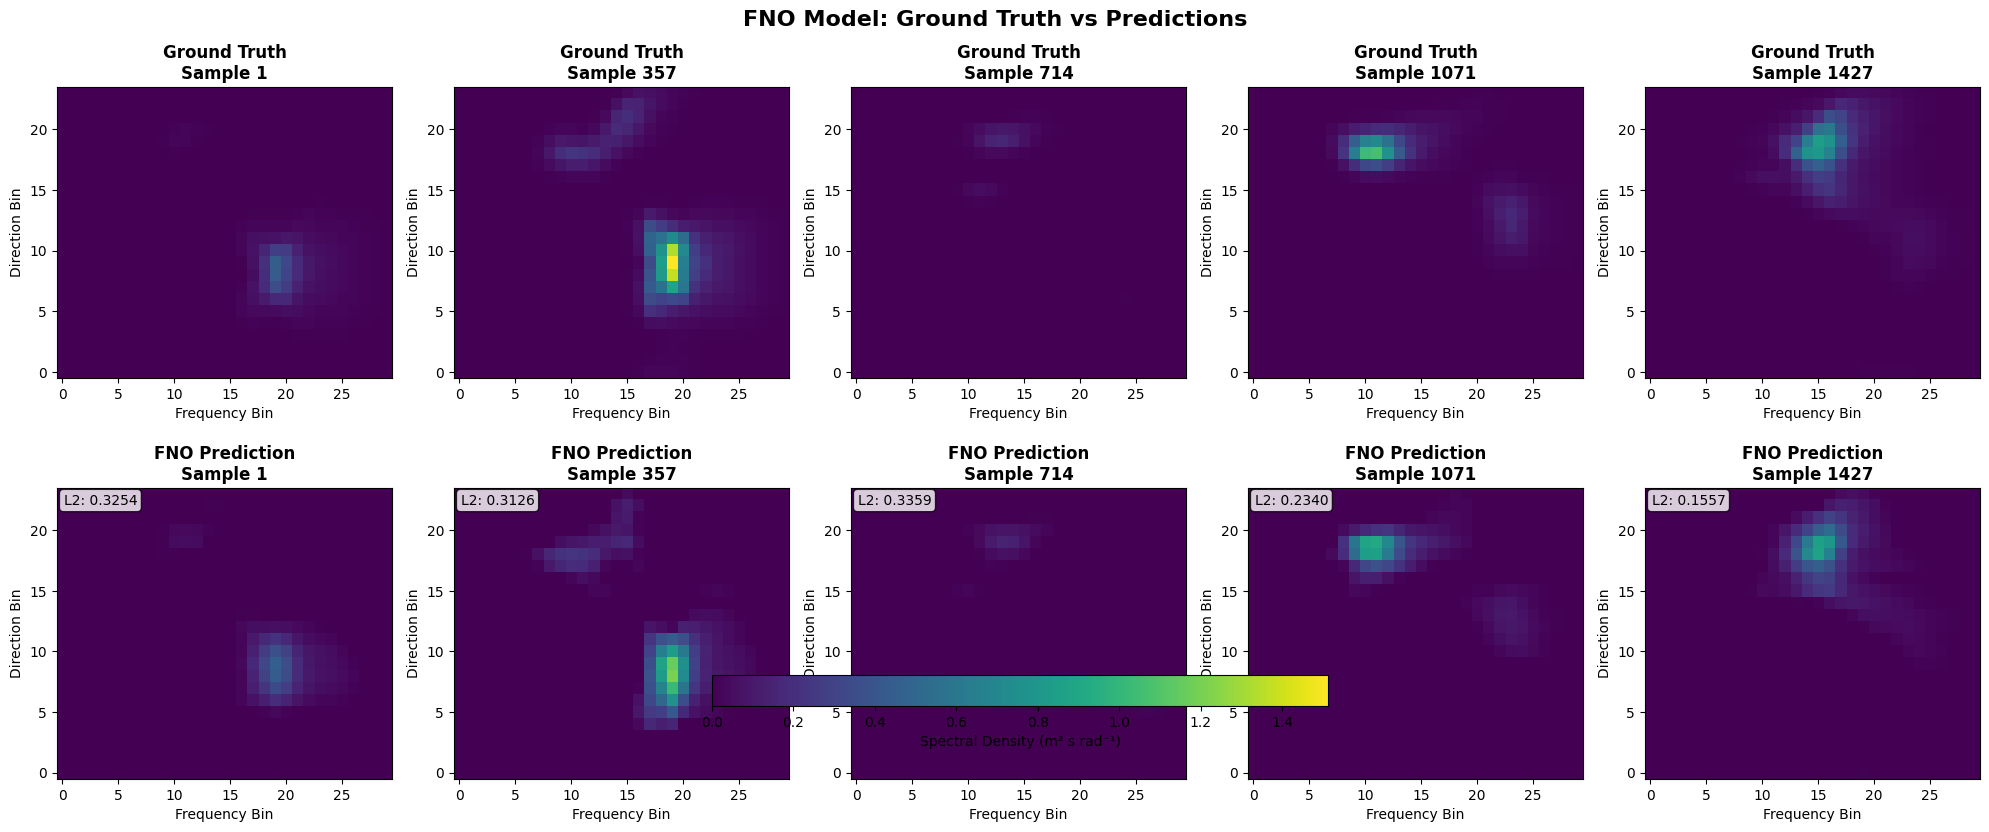

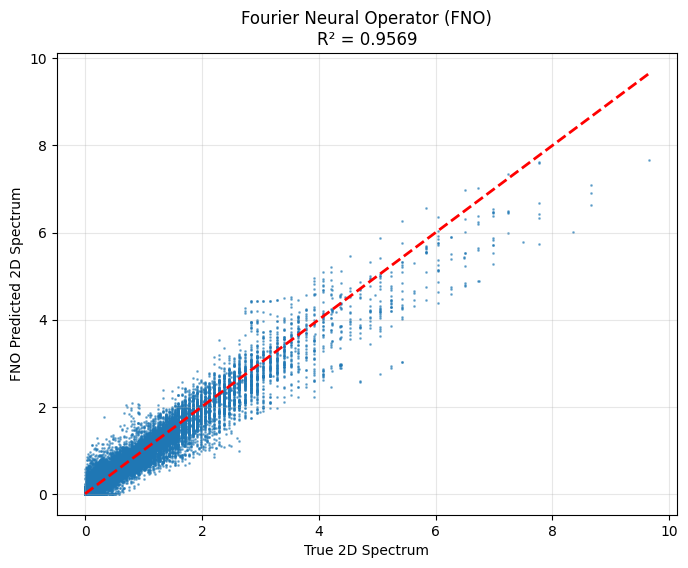


✅ FNO visualization completed!
   Model Performance: R² = 0.956945, L2 Error = 0.347907


In [10]:
# Visualization: Compare FNO predictions with ground truth
print("Creating FNO prediction visualizations...")

# Select a few representative samples for visualization
sample_indices = [0, len(test_predictions_np)//4, len(test_predictions_np)//2, 
                  3*len(test_predictions_np)//4, len(test_predictions_np)-1]
n_samples = len(sample_indices)

fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 8))
if n_samples == 1:
    axes = axes.reshape(-1, 1)

# Global colorbar limits
vmax = max(np.max(test_target_np[sample_indices]), np.max(test_predictions_np[sample_indices]))
vmin = 0

for i, idx in enumerate(sample_indices):
    # Ground truth (top row)
    im1 = axes[0, i].imshow(test_target_np[idx].T, aspect='auto', cmap='viridis',
                           vmin=vmin, vmax=vmax, origin='lower')
    axes[0, i].set_title(f'Ground Truth\nSample {idx+1}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('Frequency Bin')
    axes[0, i].set_ylabel('Direction Bin')
    
    # FNO prediction (bottom row) 
    im2 = axes[1, i].imshow(test_predictions_np[idx].T, aspect='auto', cmap='viridis',
                           vmin=vmin, vmax=vmax, origin='lower')
    axes[1, i].set_title(f'FNO Prediction\nSample {idx+1}', fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel('Frequency Bin')
    axes[1, i].set_ylabel('Direction Bin')
    
    # Add error info
    sample_l2_error = relative_l2_error[idx]
    axes[1, i].text(0.02, 0.98, f'L2: {sample_l2_error:.4f}', 
                   transform=axes[1, i].transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', 
                   facecolor='white', alpha=0.8))

# Add colorbar
fig.colorbar(im1, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1,
             label='Spectral Density (m² s rad⁻¹)')

plt.suptitle('FNO Model: Ground Truth vs Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# R² scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(test_target_np.flatten(), test_predictions_np.flatten(), alpha=0.5, s=1)
plt.plot([test_target_np.min(), test_target_np.max()], 
         [test_target_np.min(), test_target_np.max()], 'r--', lw=2)
plt.xlabel('True 2D Spectrum')
plt.ylabel('FNO Predicted 2D Spectrum')
plt.title(f'Fourier Neural Operator (FNO)\nR² = {r2_fno:.4f}')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✅ FNO visualization completed!")
print(f"   Model Performance: R² = {r2_fno:.6f}, L2 Error = {l2_fno_error:.6f}")

# 🌊 Evaluation on Independent Dataset

Evaluate the trained FNO model on completely separate evaluation data to verify generalization performance.

In [ ]:
# Load ERA5 evaluation data for FNO assessment
print("Loading ERA5 evaluation data for FNO assessment...")
model_path = "models/fno.pth"
eval_data_path = "eval_data\\gum\\2019\\01\\processed_1\\era5_wave_eval.npz"

if not os.path.exists(eval_data_path):
    print(f"❌ Evaluation data not found: {eval_data_path}")
    print("Make sure to run process.py to create evaluation dataset first")
else:
    eval_data = np.load(eval_data_path)
    
    # Load evaluation data (channel-wise format for FNO)
    eval_X = eval_data["X"]          # (time, 5, 30) - [S1D, a1, b1, a2, b2]
    eval_y = eval_data["y"]          # (time, 30, 24) - True 2D spectrum
    
    print(f"✅ Evaluation data loaded successfully")
    print(f"  eval_X shape: {eval_X.shape}")
    print(f"  eval_y shape: {eval_y.shape}")
    print(f"  Time steps: {eval_X.shape[0]}")
    
    # Extract components from evaluation data
    eval_S1D = eval_X[:, 0, :]  # 1D spectra: (samples, 30)
    eval_a1 = eval_X[:, 1, :]   # Directional moment a1: (samples, 30)
    eval_b1 = eval_X[:, 2, :]   # Directional moment b1: (samples, 30)
    eval_a2 = eval_X[:, 3, :]   # Directional moment a2: (samples, 30)
    eval_b2 = eval_X[:, 4, :]   # Directional moment b2: (samples, 30)
    
    print(f"ERA5 evaluation set: {eval_X.shape[0]} samples")
    print(f"Input channels: S1D, a1, b1, a2, b2")

Loading ERA5 evaluation data for FNO assessment...
✅ Evaluation data loaded successfully
  eval_X shape: (744, 5, 30)
  eval_y shape: (744, 30, 24)
  Time steps: 744
ERA5 evaluation set: 744 samples
Input channels: S1D, a1, b1, a2, b2


In [4]:
# Preprocess ERA5 evaluation data for FNO
if 'eval_X' in locals():
    print("Preprocessing ERA5 evaluation data for FNO...")
    
    # Load normalization parameters (saved during training)
    normalization_path = "models/fno_normalization.npz"
    if os.path.exists(normalization_path):
        norm_data = np.load(normalization_path)
        eval_input_mean = norm_data['input_mean']
        eval_input_std = norm_data['input_std']
        print(f"✅ Loaded saved normalization parameters")
    else:
        print(f"⚠️  Using evaluation data for normalization")
        eval_input_mean = eval_X.mean(axis=(0, 2), keepdims=True)
        eval_input_std = eval_X.std(axis=(0, 2), keepdims=True) + 1e-8
    
    # Normalize inputs using saved parameters (channel-wise format)
    eval_X_norm = (eval_X - eval_input_mean) / eval_input_std
    
    print(f"Normalized evaluation inputs:")
    print(f"  Range: [{eval_X_norm.min():.6f}, {eval_X_norm.max():.6f}]")
    print(f"  Shape: {eval_X_norm.shape}")
    
    # Convert to PyTorch tensors
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    eval_X_tensor = torch.FloatTensor(eval_X_norm).to(device)
    eval_y_tensor = torch.FloatTensor(eval_y).to(device)
    
    print(f"ERA5 evaluation data ready for FNO inference")
    print(f"  Device: {device}")
    print(f"  Input tensor shape: {eval_X_tensor.shape}")
    print(f"  Target tensor shape: {eval_y_tensor.shape}")
    print(f"  Input format: Channel-wise (batch, 5, 30) - matches FNO training")

else:
    print("❌ Evaluation data not loaded. Run previous cell first.")

Preprocessing ERA5 evaluation data for FNO...
✅ Loaded saved normalization parameters
Normalized evaluation inputs:
  Range: [-2.546671, 49.124270]
  Shape: (744, 5, 30)
ERA5 evaluation data ready for FNO inference
  Device: cpu
  Input tensor shape: torch.Size([744, 5, 30])
  Target tensor shape: torch.Size([744, 30, 24])
  Input format: Channel-wise (batch, 5, 30) - matches FNO training


In [5]:
# Evaluate FNO model on ERA5 evaluation set
if 'eval_X_tensor' in locals():
    print("Evaluating FNO model on ERA5 data...")
    
    # Create fresh model instance for evaluation using same parameters as training
    in_channels = 5
    width = 64
    modes = 16
    n_freq = 30
    n_dir = 24
    
    model = FNO1D_to_2D(in_channels=in_channels, width=width, modes=modes, 
                        n_freq=n_freq, n_dir=n_dir).to(device)
    
    # Load best trained model
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    # Perform inference on evaluation set
    with torch.no_grad():
        eval_pred = model(eval_X_tensor)
        
        print(f"ERA5 evaluation complete:")
        print(f"  Predictions shape: {eval_pred.shape}")
        print(f"  Prediction range: [{eval_pred.min().item():.6f}, {eval_pred.max().item():.6f}]")
        
        # Convert to numpy for analysis
        eval_pred_np = eval_pred.cpu().numpy()
        eval_target_np = eval_y_tensor.cpu().numpy()
    
    # Compute evaluation metrics
    eval_mse = np.mean((eval_pred_np - eval_target_np) ** 2)
    eval_mae = np.mean(np.abs(eval_pred_np - eval_target_np))
    
    # Compute R-squared for ERA5 evaluation
    eval_y_flat = eval_target_np.flatten()
    eval_pred_flat = eval_pred_np.flatten()
    eval_ss_tot = np.sum((eval_y_flat - np.mean(eval_y_flat)) ** 2)
    eval_ss_res = np.sum((eval_y_flat - eval_pred_flat) ** 2)
    eval_r2 = 1 - (eval_ss_res / eval_ss_tot)
    
    # L2 error calculation
    eval_y_clean = np.nan_to_num(eval_target_np, nan=0.0)
    eval_pred_clean = np.nan_to_num(eval_pred_np, nan=0.0)
    
    epsilon_l2 = 1e-10
    n_time_eval = len(eval_target_np)
    
    norm_true_eval = np.linalg.norm(eval_y_clean.reshape(n_time_eval, -1), axis=1)
    norm_diff_eval = np.linalg.norm((eval_pred_clean - eval_y_clean).reshape(n_time_eval, -1), axis=1)
    relative_l2_error_eval = norm_diff_eval / (norm_true_eval + epsilon_l2)
    l2_eval_error = np.mean(relative_l2_error_eval)
    
    # Energy conservation check
    energy_conservation_eval = np.abs(
        np.mean(np.sum(eval_pred_np, axis=(1,2))) - np.mean(np.sum(eval_target_np, axis=(1,2)))
    ) / np.mean(np.sum(eval_target_np, axis=(1,2)))
    
    print("\n" + "="*60)
    print("FNO MODEL EVALUATION ON ERA5 INDEPENDENT DATASET")
    print("="*60)
    print(f"Dataset size:                      {n_time_eval} time steps")
    print(f"MSE:                               {eval_mse:.6f}")
    print(f"MAE:                               {eval_mae:.6f}")
    print(f"L2 Error:                          {l2_eval_error:.6f}")
    print(f"R²:                                {eval_r2:.6f} ({eval_r2*100:.2f}% variance explained)")
    print(f"Energy conservation error:         {energy_conservation_eval:.6f}")
    
    # Statistics
    print(f"\nL2 error statistics:")
    print(f"  Mean: {np.mean(relative_l2_error_eval):.6f}")
    print(f"  Std:  {np.std(relative_l2_error_eval):.6f}")
    print(f"  Min:  {np.min(relative_l2_error_eval):.6f}")
    print(f"  Max:  {np.max(relative_l2_error_eval):.6f}")
    
    print("="*60)
    print("✅ FNO ERA5 evaluation completed!")
    
else:
    print("❌ Evaluation data not preprocessed. Run previous cells first.")

Evaluating FNO model on ERA5 data...
ERA5 evaluation complete:
  Predictions shape: torch.Size([744, 30, 24])
  Prediction range: [0.000000, 9.097800]

FNO MODEL EVALUATION ON ERA5 INDEPENDENT DATASET
Dataset size:                      744 time steps
MSE:                               0.042984
MAE:                               0.027391
L2 Error:                          0.614800
R²:                                0.595941 (59.59% variance explained)
Energy conservation error:         0.168783

L2 error statistics:
  Mean: 0.614800
  Std:  0.772367
  Min:  0.170985
  Max:  5.955063
✅ FNO ERA5 evaluation completed!


Creating visualization of FNO evaluation results...


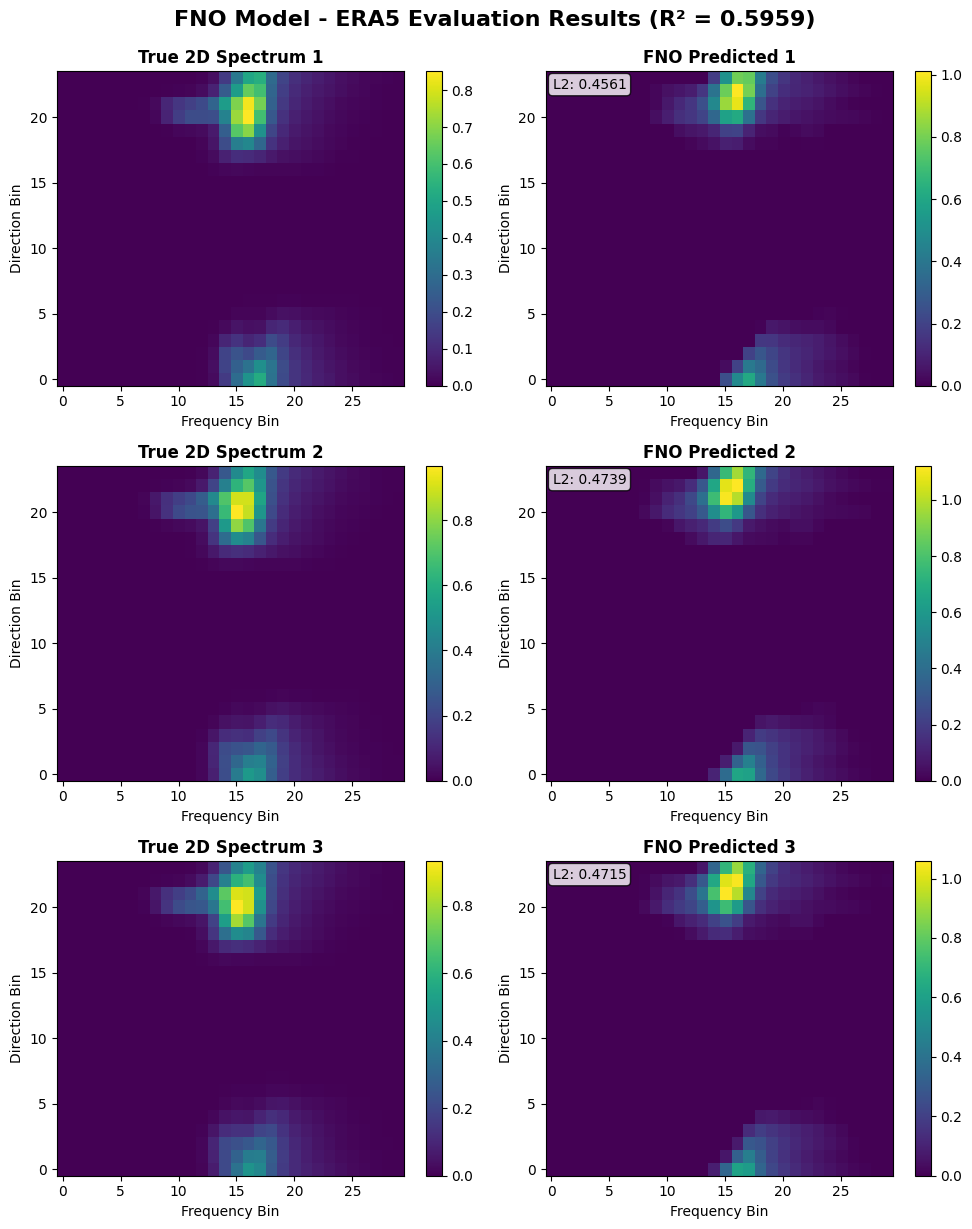

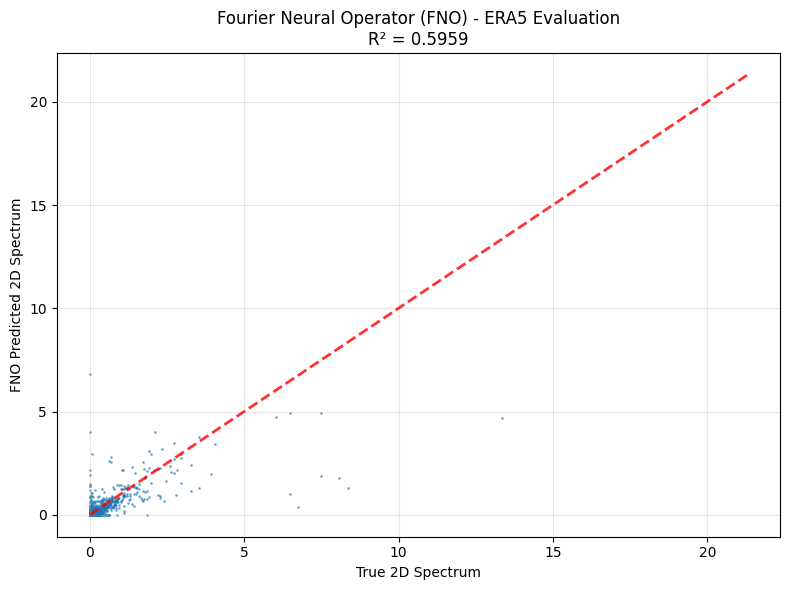


✅ FNO evaluation visualization complete!
ERA5 independent dataset performance:
  - R² = 0.595941 (59.59% variance explained)
  - RMSE = 2.073250e-01
  - L2 Error = 0.614800
  - Energy Conservation Error = 0.168783
  - Dataset size: 744 time steps


In [6]:
# Visualize FNO evaluation results on ERA5 dataset
print("Creating visualization of FNO evaluation results...")

# Use evaluation data from previous cell
if 'eval_pred_np' in locals() and 'eval_target_np' in locals():
    num_examples = min(3, eval_target_np.shape[0])

    fig, axes = plt.subplots(num_examples, 2, figsize=(10, 4*num_examples))
    if num_examples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_examples):
        # True 2D spectrum
        im1 = axes[i, 0].imshow(eval_target_np[i].T, aspect='auto', cmap='viridis', 
                                origin='lower', interpolation='nearest')
        axes[i, 0].set_title(f'True 2D Spectrum {i+1}', fontsize=12, fontweight='bold')
        axes[i, 0].set_xlabel('Frequency Bin')
        axes[i, 0].set_ylabel('Direction Bin')
        plt.colorbar(im1, ax=axes[i, 0])
        
        # FNO predicted 2D spectrum  
        im2 = axes[i, 1].imshow(eval_pred_np[i].T, aspect='auto', cmap='viridis',
                                origin='lower', interpolation='nearest')
        axes[i, 1].set_title(f'FNO Predicted {i+1}', fontsize=12, fontweight='bold')
        axes[i, 1].set_xlabel('Frequency Bin')
        axes[i, 1].set_ylabel('Direction Bin')
        plt.colorbar(im2, ax=axes[i, 1])
        
        # Add L2 error for this sample
        sample_l2_error = relative_l2_error_eval[i]
        axes[i, 1].text(0.02, 0.98, f'L2: {sample_l2_error:.4f}', 
                       transform=axes[i, 1].transAxes, fontsize=10,
                       verticalalignment='top', bbox=dict(boxstyle='round', 
                       facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.suptitle(f'FNO Model - ERA5 Evaluation Results (R² = {eval_r2:.4f})', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.show()

    # Create scatter plot for evaluation data
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    # Sample points for better visualization
    n_points = 10000
    indices = np.random.choice(len(eval_y_flat), min(n_points, len(eval_y_flat)), replace=False)

    ax.scatter(eval_y_flat[indices], eval_pred_flat[indices], alpha=0.5, s=1)
    min_val = min(eval_y_flat.min(), eval_pred_flat.min())
    max_val = max(eval_y_flat.max(), eval_pred_flat.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    ax.set_xlabel('True 2D Spectrum')
    ax.set_ylabel('FNO Predicted 2D Spectrum')
    ax.set_title(f'Fourier Neural Operator (FNO) - ERA5 Evaluation\nR² = {eval_r2:.4f}')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n✅ FNO evaluation visualization complete!")
    print(f"ERA5 independent dataset performance:")
    print(f"  - R² = {eval_r2:.6f} ({eval_r2*100:.2f}% variance explained)")
    print(f"  - RMSE = {np.sqrt(eval_mse):.6e}")
    print(f"  - L2 Error = {l2_eval_error:.6f}")
    print(f"  - Energy Conservation Error = {energy_conservation_eval:.6f}")
    print(f"  - Dataset size: {n_time_eval} time steps")
    
else:
    print("❌ No evaluation data available. Run previous cells first.")